In [1]:
"""
Burger's equation calculation for Fig. 3. Change variable "run" to specify which initial condition to use
1: cosine
2: shock propagation
3: rarefaction

Driver: 1-D inviscid Burgers equation test case.

Solves du/dt + u du/dx = 0 (flux form du/dt + 1/2 d/dx u**2 = 0) on a
quantized-tensor-train grid and compares against a reference solution.
Reference: https://zingale.github.io/comp_astro_tutorial/advection_euler/burgers/burgers-methods.html
"""

'\nBurger\'s equation calculation for Fig. 3. Change variable "run" to specify which initial condition to use\n1: cosine\n2: shock propagation\n3: rarefactio\n\nDriver: 1-D inviscid Burgers equation test case.\n\nSolves du/dt + u du/dx = 0 (flux form du/dt + 1/2 d/dx u**2 = 0) on a\nquantized-tensor-train grid and compares against a reference solution.\nReference: https://zingale.github.io/comp_astro_tutorial/advection_euler/burgers/burgers-methods.html\n'

In [11]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys, time, glob

import scipy.optimize

sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt

import setup_.paths
from setup_.configs import *
import setup_.helper as helper_test
import helper_quimb as helper
import setup_test as test_setup

from axis import Axis
from basis.basis_spatial import SpatialBasis
from coord.coord_sys import Coordinate
from coord.cartesian import CartesianCoordinateSpace
from grid1D import Grid1D
from gridTN_1D import GridTN1D
from field import Field, ScalarField

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
save_figs = False
save_data = True
load_data = False
restart = False
restart_from_T = 0  ## to restart from an output file (vs a saved restart file)
verbose = False

if restart or save_data or save_figs:
    fdir = './data_cross/Burgers/'
    os.makedirs(fdir, exist_ok=True)
    print('fdir', fdir)

fdir ./data_cross/Burgers/


In [13]:
######################
# problem parameters #
######################

## Burgers equation
upwind = True   # whether or not to use upwinding
nu = 0.0 if upwind else 0.003 / max(1,Lx-7)**2 # 0.003       ## viscosity
flux_coeff = 1.0        ## non-linear flux coeff
Lbox = 1.0

run = 2
## 1: cosine, 2: shock propagation, 3: rarefaction

flags['x_version'] = 'proj'
## 'proj' for projected mixed cross interpolation. default is 'select'
## this is important for best results with run 2

print('upwind?', upwind)

if run == 1:    ## cosine shock
    def init_state(x):
        return np.sin(2 * np.pi * x / Lbox)
elif run == 2:
    ## shock propgation
    def init_state(x):
        return (x <= 0.5) * 1.0
elif run == 3:
    ## rarefaction
    def init_state(x):
        return (x > 0.5) * 1.0


##############################
# QTT / grid parameters #
##############################

## grid resolution
q = 2   # physical dimension of tensor core
KX = 1  # number of dimensions (only KX=1 developed)
Lx = 9  # number of tensor cores --> grid resolution = q**Lx

## QTT mapping
TN_layout = LayoutType.SEQUENTIAL
x_map_key = 'F'

## Finite difference stencil (centered stencil of order * 2)
order = 1 
if order > 1:
    extra_str += f'_o{order}'

T = 0.25 if run == 3 else 0.5   # runtime 
dt_frac = 0.9   # fraction of CFL time step (assuming no dissipation)
save_every_nt = flags.get('save_every_nt', 1000)

## specify boundary conditions
if run==1:
    deriv_x = DerivativeConfiguration(left_bc=BCType.PERIODIC, order=order, fd_type=FDType.CENTER)
else:
    deriv_x = DerivativeConfiguration(left_bc=BCType.SYMMETRIC, order=order, fd_type=FDType.CENTER)

upwind? True


In [14]:
##############################
## initialize Axes and Grid ##
##############################

x_map = helper_test.get_maps(x_map_key)[0]
ax_x = Axis(Lx, q, dx=Lbox/(q**Lx), endpoint=False, ax_map=x_map, basis=SpatialBasis())
grid_X = Grid1D('GX', [ax_x], TN_layout)
coords_x = CartesianCoordinateSpace('X', ax_x)

### time step info
dt = ax_x.dx / 1.0 * dt_frac
num_tsteps = int(T / dt)
print('T', T, 'dt', dt, 'num_tsteps', num_tsteps)

print('ax map', ax_x.map)
print('cfl dt', ax_x.dx / 1.0)    ### shock speed = (flux left - flux right)/ax.dx


T 0.5 dt 0.0017578125 num_tsteps 284
ax map <axis_map.map_binary.BinaryMap object at 0x70330103f510>
cfl dt 0.001953125


In [15]:
########################
## dense upwind calc ###
########################

def euler_upwind(dx, dt: Numeric, vec: np.ndarray):
    """ perform a single time-step update at the specified indices
    https://zingale.github.io/comp_astro_tutorial/advection_euler/burgers/burgers-methods.html
        upwinding for Burgers:
        shock speed = (F(u_r) - F(u_l)) / (u_r - u_l) = 1/2 (u_r + u_l)

        shock solution
        --> u_s = u_{i+0.5,L} if S > 0;  u_{i+0.5,R} if S < 0
        rarefaction solution
        --> u_r = u_{i+0.5,L} if u_{i+0.5,L} > 0; u_{i+0.5,R} if u_{i+0.5,R} < 0: 0 o.w.

        solution to Riemann problem
        u_{i+1/2} = u_s if u_{i+1/2,L} > u_{i+1/2,R} else u_r
        F_{i+1/2} = u_{i+1/2}^2 / 2
        d/dx F_{i} = 1/dx (F_{i+1/2} - F_{i-1/2})
    """
    npts = len(vec)
    left_bc, right_bc = deriv_x.bc
    left_offset, right_offset = deriv_x.offset, deriv_x.offset_r

    out_data = np.zeros(vec.shape)
    for ind, val in enumerate(vec):

        ix0, sign0 = ind - 1, 1
        if ind == 0:
            if left_bc in [BCType.PERIODIC, BCType.ANTIPERIODIC]:
                ix0 = npts - 1
                sign0 = np.sign(left_bc.value)
            elif left_bc in [BCType.ZEROGRADIENT, BCType.SYMMETRIC, BCType.NEUMANN]:
                ix0 = 1
                sign0 = 1
            elif left_bc in [BCType.ZEROVALUE, BCType.ANTISYMMETRIC, BCType.DIRICHLET]:
                ix0 = 1
                sign0 = 0 if left_offset == 0 else -1

        ix2, sign2 = ind + 1, 1
        if ind == npts - 1:
            if right_bc in [BCType.PERIODIC, BCType.ANTIPERIODIC]:
                ix2 = 0
                sign2 = np.sign(right_bc.value)
            elif right_bc in [BCType.ZEROGRADIENT, BCType.SYMMETRIC, BCType.NEUMANN]:
                ix2 = npts - 1
                sign2 = 1
            elif right_bc in [BCType.ZEROVALUE, BCType.ANTISYMMETRIC, BCType.DIRICHLET]:
                ix2 = npts - 1
                sign2 = 0 if right_offset == 0 else -1

        val0 = vec[ix0]
        val2 = vec[ix2]

        ### compute shock speed at left, right boundary
        def get_flux(lval, rval):
            S_ = (lval + rval) / 2
            if lval > val:
                ## shock soln
                u_ = lval if S_ > 0 else rval
            else:
                ## rarefaction soln
                if lval > 0:
                    u_ = lval
                elif rval < 0:
                    u_ = rval
                else:
                    u_ = 0.0
            return u_ ** 2 / 2

        flux_left = get_flux(val0 * sign0, val)
        flux_right = get_flux(val, val2 * sign2)

        out_data[ind] = val + dt / dx * (flux_left - flux_right)

    return out_data


In [16]:
########################
#### run simulation ####
########################

def run_burgers(te_order, tol=1.0e-14, DMAX=None):

    cutoff = tol**2   ## a result of how cutoff is defined in quimb library

    ### get file naming string
    fstr = f'burgers{run}_L{Lx}_te{te_order}_dt{dt}_T{T}_nu{nu}_nl{flux_coeff}_c{cutoff}'
    if upwind:
        fstr += '_up'
    print('filename', fstr)
    
    ## specify QTT compression
    compress_config = CompressionConfiguration()
    for i in range(1,3):
        compress_config.set_compress_opts(i, max_bond=DMAX, cutoff_mode=CUTOFF_MODE, cutoff=cutoff)
        # set compression parameters for internal/intermediate stages (otherwise default to high precision DMAX=None, cutoff=1.0e-28)
    

    ###################################
    ## define initial gridTNs (QTTs) ##
    ###################################
    
    init_u_gtn = grid_X.make_gridTN(init_state(ax_x.xpts))
    init_u_gtn.ax_deriv_configs.update({ax_x: deriv_x})
    
    #### define fields
    init_u_field = ScalarField('u', grid_X, data=init_u_gtn, is_sqrt=False, compress_config=compress_config)
    
    ############################
    ##### initialize tests ###
    ############################
    
    ts = [0]
    errs_dist = [0.0]
    tangent_space_errs = [0.0]
    us = [init_state(ax_x.xpts)]
    nt = 0
    
    print('init bond dims', init_u_gtn.max_bond())
    max_bond_fe = [init_u_gtn.max_bond()]
    max_bond_fe_glob = [init_u_gtn.max_bond()]
    
    norm_u = init_u_gtn.norm(is_sqrt=True)  ## compute ||u||^2
    print('field norm', norm_u)
    
    from pde_burgers import Burgers
    
    ### BUILD PDE
    bg_sys = Burgers(init_u_field, dissip_coeff=nu, flux_coeff=flux_coeff, power=2,
                     normalize=False, zipup=True, te_order=te_order,
                     upwind=upwind)
    bg_sys_global = Burgers(init_u_field.copy(), dissip_coeff=nu, flux_coeff=flux_coeff, power=2,
                        normalize=False, zipup=True, te_order=1 if te_order in [81, 61, 86, 66, 96, 91] else 4,
                        upwind=False)
    print('initialized Burgers')
    

    # ### plot initial state
    # fig1, ax1 = plt.subplots(1, 1)
    # time_ = nt * dt
    # u_data = init_u_gtn.get_data()
    # u_data = ax_x.basis.get_realspace_1D(u_data, 0)
    # ax1.plot(ax_x.xpts, np.real(u_data), label=f't={time_:2.2f}')
    # ax1.plot(ax_x.xpts, u_data**2, label='u2')
    # ax1.plot(ax_x.xpts[:-1], np.diff(u_data**2), label='deriv')
    # ax1.set_title(f'time {time_:3.2f}')
    # ax1.set_xlabel('x'), ax1.set_ylabel('u')
    # plt.show()
    
    
    time1 = time.time()
    internal_num_evals = [np.nan]
    internal_ranks = [init_u_gtn.max_bond()]
    
    print('starting time evolution')
    while ts[-1] < T:
    
        dt_ = (dt * 0.1) if nt == 0 else dt
    
        # print('dt/dx', dt_/ax_x.dx, dt_/(ax_x.dx**2))
    
        walltime = time.time()
        bg_sys = bg_sys.next_time_step(dt_, compress_level=1, verbose_plot=False, is_first_time_step=(nt==0 and not upwind)
                                       )
        if verbose:
            print('wall time per time step', time.time() - walltime)
    
        u_field: 'ScalarField' = bg_sys.f
        internal_ranks += [u_field.component.info.get('internal_rank', np.nan)]
        internal_num_evals += [u_field.component.info.get('num_evals', np.nan)]
    
        ## measure error between global and local
        if upwind:
            prev_u_data = bg_sys_global.f.get_comp_data()
            new_u_data = euler_upwind(ax_x.dx, dt_, prev_u_data)
            u_glob_gtn = grid_X.map_state_to_mps(new_u_data) #, split_opts={'cutoff': cutoff, 'cutoff_mode': CUTOFF_MODE})
            u_glob = u_field.copy()
            u_glob.component = u_glob_gtn
        else:
            bg_sys_global = bg_sys_global.next_time_step(dt_, compress_level=5, verbose_plot=False, )
            u_glob = bg_sys_global.f.copy()
    
        ### error from DLRA (before final compression) wrt exact time step
        ts_err = u_glob.component.copy().distance(bg_sys.f.component.copy())
        tangent_space_errs += [ts_err]    

        if verbose:
            print('pre compress ranks', helper.inner_bond_sizes(u_field.component.info['internal_rank']))
            print('post compress ranks', helper.inner_bond_sizes(u_field.component.data))
        max_bond_fe += [u_field.component.max_bond()]
    
        u_glob_trunc = u_glob.copy()
        u_glob_trunc.compress()
        max_bond_fe_glob += [u_glob_trunc.component.max_bond()]
    
        bg_sys_global.f = bg_sys.f.copy()
    
        ts += [ts[-1] + dt_]
        # us += [u_field.get_field_data()]
        nt += 1
    
        norm_u = u_field.component.norm(is_sqrt=True)

        if verbose:
            print('result', nt, ts[-1], dt, norm_u, 'u max bond', u_field.max_bond(), 'Lx', Lx)
            print('u glob max bond', u_glob.max_bond())
            print('completed time integration with te order', te_order)
            print('wall time', time.time() - time1)
    

    u_data = u_field.get_comp_data()
    if save_data:
        np.save(fdir + fstr +  '_ranks.npy', np.array([ts, max_bond_fe]))
        np.save(fdir + fstr +  '_u.npy', u_data)
        np.save(fdir + fstr + '_ts_errs.npy', np.array([ts, tangent_space_errs]))
        np.save(fdir + fstr + '_glob_rank.npy', np.array([ts, max_bond_fe_glob]))
        np.save(fdir + fstr + '_cost.npy', np.array([ts, internal_ranks, internal_num_evals]))

    return u_data, [ts, tangent_space_errs, internal_num_evals]


filename burgers2_L9_te86_dt0.0017578125_T0.5_nu0.0_nl1.0_c1e-28_up
init bond dims 2
field norm 0.7084865030471638
initialized Burgers
starting time evolution
filename burgers2_L9_te86_dt0.0017578125_T0.5_nu0.0_nl1.0_c1e-08_up
init bond dims 2
field norm 0.7084865030471638
initialized Burgers
starting time evolution
filename burgers2_L9_te96_dt0.0017578125_T0.5_nu0.0_nl1.0_c1e-08_up
init bond dims 2
field norm 0.7084865030471638
initialized Burgers
starting time evolution


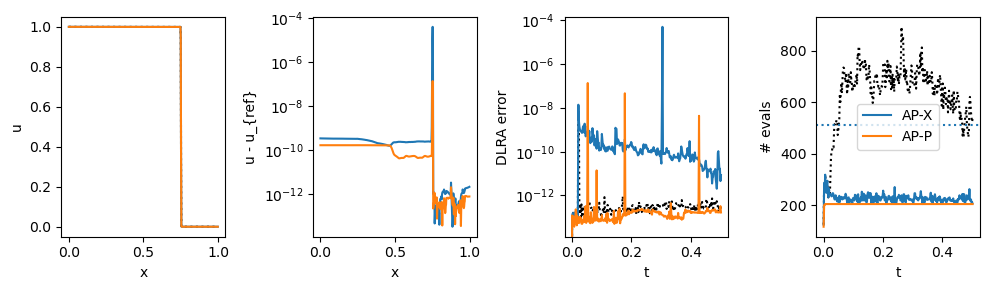

In [18]:
###############################
### run tests and plot data ###
###############################

ref_data, [ts, tangent_space_errs, internal_num_evals] = run_burgers(86)

fig1, ax1s = plt.subplots(1, 4, figsize=(10,3))

xs = ax_x.xpts
ax1s[0].plot(xs, ref_data, 'k:', label='ref')
ax1s[2].semilogy(ts, tangent_space_errs, 'k:')
ax1s[3].plot(ts, internal_num_evals, 'k:')

## run tests for different time integration schemes
for te_order, label in [(86, 'AP-X'), (96, 'AP-P')]:
    ## 86:  alternative projection DLR-X + Euler (upwinding if upwind=True)
    ## 96:  alternative projection DLR-P + Euler

    out_data, [ts, tangent_space_errs, internal_num_evals] = run_burgers(te_order, tol=1.0e-04)

    ax1s[0].plot(xs, out_data, label=label)
    ax1s[1].semilogy(xs, np.abs(out_data - ref_data))
    ax1s[2].semilogy(ts, tangent_space_errs)
    ax1s[3].plot(ts, internal_num_evals, label=label)

ax1s[3].axhline(q**Lx, ls=':')
ax1s[0].set_xlabel('x')
ax1s[0].set_ylabel('u')
ax1s[1].set_xlabel('x')
ax1s[1].set_ylabel('u - u_{ref}')
ax1s[2].set_xlabel('t')
ax1s[2].set_ylabel('DLRA error')
ax1s[3].set_xlabel('t')
ax1s[3].set_ylabel('# evals')

ax1s[-1].legend()
fig1.tight_layout()
plt.show()
    
